### 1. Introducción 

El modelo principal de referencia en el sector bancario para Application Scoring  (scoring de admisión) es la **Regresión Logística con transformación WoE** (Weight of Evidence, peso de la evidencia). Su adopción está respaldada por las guías de la  EBA (European Banking Authority, Autoridad Bancaria Europea) sobre modelos IRB  (Internal Ratings-Based, basados en calificaciones internas), y su interpretabilidad  directa facilita la validación regulatoria.

El objetivo de esta fase es construir un **benchmark**:  entrenar modelos alternativos y evaluar si ofrecen una capacidad discriminante  superior al modelo campeón.

#### 1.1 Métodos elegidos para realizar el benchmark

He seleccionado modelos de Gradient Boosting (potenciación del gradiente) por las  siguientes razones:

1. **Rendimiento empírico superior** en datos tabulares financieros, documentado en  la literatura de referencia sobre scoring crediticio (Lessmann et al., 2015).
2. **Robustez ante outliers (valores atípicos) y variables asimétricas**,  características predominantes en el dataset HMEQ identificadas durante el EDA.
3. **Gestión nativa de missing values (valores ausentes)** en LightGBM, evitando decisiones de imputación que podrían introducir sesgo.

Se entrenan dos implementaciones para validar la estabilidad de los resultados:
- **LightGBM**: optimizado en memoria y velocidad, gestiona los valores ausentes de forma nativa.
- **XGBoost**: implementación clásica ampliamente auditada en entornos bancarios, requiere imputación previa de valores ausentes.

En relación con la evaluación, se emplean las mismas métricas que en la Regresión Logística, permitiendo una comparación homogénea: AUC-ROC , KS , Gini y Brier Score.

#### 1.2 Métodos descartados

- **Random Forest** (familia bagging): menor poder predictivo empírico que boosting en datos tabulares financieros (Lessmann et al., 2015). Al ser también un conjunto de árboles, no aporta información adicional sobre el techo de discriminación que ya estima el estado del arte (boosting).
- **Redes neuronales**: actúan como "caja negra" sin un beneficio claro sobre boosting en datasets de tamaño moderado, lo que dificulta su defensa ante el regulador.
- **SVM** (Support Vector Machine, máquina de vectores de soporte): de la familia de métodos kernel, no produce probabilidades calibradas de forma directa; está diseñado para clasificación binaria dura, no para scoring continuo.
- **KNN** (K-Nearest Neighbors, K vecinos más cercanos): muy sensible a la escala y a la dimensionalidad, y sin capacidad de extrapolación.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.base import clone 

### 2. Carga de datos

In [2]:
# Cargar el dataset y hacer una copia
hmeq = pd.read_csv('../data/raw/hmeq.csv')
hmeq_prep_2 = hmeq.copy()

### 3. Pipeline de preprocesamiento y modelización

#### 3.1 Separación train/test

In [3]:
# train y test split
X = hmeq_prep_2.drop(columns="BAD")
y = hmeq_prep_2["BAD"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=123, stratify=y)    

In [4]:
print(f"Total : {len(X)}")
print(f"Train : {len(X_train)}")
print(f"Test: {len(X_test)}")
print(f"Proporción de defaults):")
print(f"Total : {y.mean():.3f}")
print(f"Train : {y_train.mean():.3f}")
print(f"Test  : {y_test.mean():.3f}")

Total : 5960
Train : 4172
Test: 1788
Proporción de defaults):
Total : 0.199
Train : 0.199
Test  : 0.200


#### 3.2 Pipeline de preprocesamiento: ColumnTransformer (9)

El preprocesamiento se implementa mediante un ColumnTransformer
Se definen tres grupos de variables:

**Variables numéricas para LightGBM:**
Creación de CLTV, cap en 2.55 y eliminación de MORTDUE y VALUE.
LightGBM gestiona missing values de forma nativa — no se imputan.

**Variables numéricas para XGBoost:**
Idéntico tratamiento más imputación por mediana.
XGBoost no gestiona missing values nativamente.

**Variables categóricas (ambos modelos):**
REASON y JOB — missing como categoría explícita + OrdinalEncoder.
Se usa OrdinalEncoder en lugar de LabelEncoder porque es compatible
con el pipeline de scikit-learn.

In [5]:
from sklearn.pipeline import Pipeline  
from sklearn.compose import ColumnTransformer  
from sklearn.preprocessing import OrdinalEncoder # Codificación ordinal para categóricas
from sklearn.impute import SimpleImputer # Imputación de missing values
from sklearn.base import BaseEstimator, TransformerMixin, clone  # Base para crear transformadores propios y clonar modelos
import shap   # explicabilidad de modelos
from sklearn.metrics import roc_auc_score, brier_score_loss, log_loss  # métricas
from scipy.stats import ks_2samp                                        # metricas


#### 3.2.bis — Clase propia CLTVTransformer

La clase `CLTVTransformer`, responsable de construir la variable Combined Loan-to-Value dentro del pipeline, se ha extraído al módulo compartido `src/transformers.py` para:

- Evitar duplicación de código entre los notebooks 03 (LightGBM), 04 (XGBoost) y 05 (comparación de modelos).
- Permitir que los Pipelines serializados con `joblib.dump` apunten a una referencia estable (`src.transformers.CLTVTransformer`) en vez de `__main__`, lo que permite cargarlos desde cualquier notebook posterior sin reproducir la definición.

Esta separación sigue el patrón estándar en entornos bancarios de producción, donde los transformers personalizados se empaquetan en librerías internas auditables.

In [6]:
#  Importar clase propia desde módulo compartido src/ 
import sys                                               # Módulo estándar para manipular el path de Python
from pathlib import Path                                 # Manejo de rutas multiplataforma
sys.path.append(str(Path.cwd().parent))                  # Añadir la raíz del proyecto al path de Python
from src.transformers import CLTVTransformer             # Importar desde el módulo compartido

In [7]:
# Variables categóricas — requieren encoding
vars_categoricas = ["REASON", "JOB"]

# Variables numéricas originales — MORTDUE y VALUE se eliminan dentro del
# CLTVTransformer, por lo que no se incluyen aquí como destino final
vars_numericas = ["LOAN", "YOJ", "DEROG", "DELINQ", "CLAGE", "NINQ", "CLNO", "DEBTINC", "MORTDUE", "VALUE"]

print("Variables categóricas :", vars_categoricas)
print("Variables numéricas   :", vars_numericas)

Variables categóricas : ['REASON', 'JOB']
Variables numéricas   : ['LOAN', 'YOJ', 'DEROG', 'DELINQ', 'CLAGE', 'NINQ', 'CLNO', 'DEBTINC', 'MORTDUE', 'VALUE']


#### 3.3 Construcción de los pipelines

Se construyen dos pipelines independientes, uno por modelo. Ambos comparten la lógica de preprocesamiento pero difieren en el tratamiento de missing values en variables numéricas:

- **Pipeline LightGBM**: no imputa missing values numéricos. LightGBM aprende internamente la dirección óptima para los NaN  minimizando la función de pérdida en cada split, lo que constituye una ventaja metodológica.

- **Pipeline XGBoost**: imputa missing values numéricos con la mediana calculada exclusivamente sobre el conjunto de train, evitando data leakage desde el conjunto de test.

En ambos casos las variables categóricas reciben el mismo tratamiento: missing imputado como categoría explícita "Missing" seguido de OrdinalEncoder, que asigna un entero a cada categoría.

In [8]:
# Construcción del pipeline de preprocesamiento
import lightgbm as lgb    # Modelo LightGBM
import xgboost as xgb     # Modelo XGBoost

# Preprocesamiento variables categoricas. Aplica a ambos modelos, LightGBM y XGBoost.
prep_categoricas = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")), # Imputación de missing values con la categoría "missing"
    ("encoder", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)) # Codificación ordinal, asignando -1 a categorías desconocidas. Esto nos da una señal inequívoca de categoría desconocida en vez de "romper" el pipeline. 
])

# Preprocesamiento variables numéricas. 
# 1. LightGBM: Solo aplicamos el CLTVTransformer, ya que LightGBM maneja internamente los missing values. 

prep_numericas_lightgbm = Pipeline(steps=[
    ("cltv", CLTVTransformer(cap=2.55)) # Calcula CLTV, aplica CAP y elimina MORTDUE y VALUE 
])

prep_numericas_xgb = Pipeline(steps=[
    ("cltv", CLTVTransformer(cap=2.55)),
    ("imputer", SimpleImputer(strategy="median"))
])

In [9]:
# Definimos el columntransformer para cada modelo. 
# 1. LightGBM
preprocessor_lightgbm = ColumnTransformer(transformers=[
    ("num", prep_numericas_lightgbm, vars_numericas),
    ("cat", prep_categoricas, vars_categoricas)
], remainder="drop") # Solo mantiene las columnas transformadas. 

preprocessor_lightgbm

,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,cap,2.55
,missing_values,nan
,strategy,'constant'


In [10]:
# 2. XGBoost
preprocessor_xgb = ColumnTransformer(transformers=[
    ("num", prep_numericas_xgb, vars_numericas),
    ("cat", clone(prep_categoricas), vars_categoricas) # usamos clone para evitar que el mismo objeto prep_categoricas se comparta entre ambos pipelines, lo que podría causar problemas si se ajusta en uno de ellos.
], remainder="drop")

preprocessor_xgb

,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,cap,2.55
,missing_values,nan
,strategy,'median'


In [11]:
# Pipelines finales (preprocesamiento más modelo)
# Los hiperparámetros (n_estimators, max_depth, learning_rate, etc) se fijarán mas adelante con GridsearchCV. Tan solo se fijan parámetros fijos. 
# 1. LightGBM
pl_lgbm = Pipeline(steps=[
    ("prep_light", preprocessor_lightgbm),
    ("model_light", lgb.LGBMClassifier(
        objective="binary",
        random_state=123,
        n_jobs=-1)) # usamos todos los nucleos. Sacrificamos RAM para aumentar la velocidad de entrenamiento.
])
pl_lgbm

,steps,"[('prep_light', ...), ('model_light', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [12]:
# Pipelines finales (preprocesamiento más modelo)
# Los hiperparámetros (n_estimators, max_depth, learning_rate, etc) se fijarán mas adelante con GridsearchCV. Tan solo se fijan parámetros fijos. 
# 2. XGBoost
pl_xgb = Pipeline(steps=[
    ("prep_xgb", preprocessor_xgb),
    ("model_xgb", xgb.XGBClassifier(
        objective="binary:logistic",
        random_state=123,
        n_jobs=-1)) # usamos todos los nucleos. Sacrificamos RAM para aumentar la velocidad de entrenamiento.
])
    
pl_xgb

,steps,"[('prep_xgb', ...), ('model_xgb', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


#### 3.4 Busqueda de Hiperparámetros LightGBM (20)

Usaremos GridsearchCV con validación cruzada estratificada de 5 folds sobre el conjunto de train. Debido principalmente al coste computacional, nos centraremos en aquellos hiperparámetros que más impacto tiene sobre el rendimiento y el riesgo de overfitting.
LightGBM utiliza una estrategia de crecimiento Leaf-wise basada en la hoja con la mayor reducción de pérdida. Esta estrategia minimiza de forma mucho más eficiente la función de pérdida global que permite capturar relaciones e interacciones complejas y no lineales entre variables financieras altamente discriminantes.
En concreto, en el modelo de boosting emplearemos:
- **n_estimators**: Es el número de arboles y por lo tanto la **capacidad** del modelo para aprender. 
- **max_depth**: profundidad o **complejidad** de cada arbol. Es decir, el número de preguntas que ocurren sobre el dato. El riesgo de overfitting surge en arboles profundos. 
- **num_leaves**: número máximo de hojas por árbol. Específico del crecimiento leaf-wise de LightGBM, controla cuántas particiones efectivas realiza el algoritmo en cada árbol. Su interacción con max_depth es relevante: num_leaves ≤ 2^max_depth, en caso contrario el árbol no llegará al número solicitado.
- **learning_rate**: establece cuanto peso le damos a esa corrección y por lo tanto determina la **velocidad de convergencia** . Un learning_rate alto da pasos grandes y aprende rápido pero puede oscilar y no converger. El riesgo: overfitting/underfitting no depende unicamente de learning_Rate si no de la interacción del hiperparámetro con otros. 
- **min_child_samples**: **Regulariza** que cada hoja del árbol tenga un mínimo de observaciones antes de crearse

Consideramos resto refinamientos secundarios que solo justifican usarlos si el modelo muestra señales claras de overfitting tras la optimización.

##### 3.4.1 Busqueda de Hiperparámetros LightGBM (Modelo optimizado por AUC sin restricciones)

In [13]:
from sklearn.model_selection import GridSearchCV   
from sklearn.model_selection import StratifiedKFold  

In [14]:
# Metricas de 3 grids

cv_estratificado = StratifiedKFold(n_splits=5, shuffle=True, random_state=123) # Validación cruzada estratificada de 5 folds 

# Hiperparámetros a probar para LightGBM.

param_grid_lgbm_1 = {
    "model_light__n_estimators"    : [100, 300, 500],       # Número de árboles
    "model_light__max_depth"       : [3, 5, 7],           # Profundidad máxima por árbol
    "model_light__learning_rate"   : [0.01, 0.05, 0.1],     # Velocidad de aprendizaje
    "model_light__min_child_samples": [10, 20, 50, 100]         # Mínimo de observaciones por hoja — regularización
} # Este grid tarda unos 15 mins en entrenar con n_jobs=-1

gs_lgbm_principal_1 = GridSearchCV(
    estimator=pl_lgbm,  # El estimator será el pipeline completo: preprocesamiento + modelo
    param_grid=param_grid_lgbm_1, # Hiperparámetros a probar
    cv=cv_estratificado, # Esta CV  estratificada (mantiene el % de BAD en cada fold)
    scoring="roc_auc", # Métrica de optimización: AUC-ROC ya que es más robusta en datasets desbalanceados
    # verbose=1,
    return_train_score=True, # Guarda también el score en train — útil para detectar overfitting
    n_jobs=-1 
)

param_grid_lgbm_2 = {
    "model_light__n_estimators"    : [100, 300, 500], 
    "model_light__max_depth"       : [3, 5, 7],           
    "model_light__num_leaves"      : [15, 31, 63],       # Número de hojas por árbol.
    "model_light__learning_rate"   : [0.01, 0.05, 0.1],
    "model_light__min_child_samples": [10, 20, 50, 100] 
} # Este grid tarda unos 40 mins en entrenar con n_jobs=-1 y el best param_grid es 500, 7, 63, 0.1, 10

gs_lgbm_principal_2 = GridSearchCV(
    estimator=pl_lgbm,  # El estimator será el pipeline completo: preprocesamiento + modelo
    param_grid=param_grid_lgbm_2, # Hiperparámetros a probar
    cv=cv_estratificado, # Esta CV  estratificada (mantiene el % de BAD en cada fold)
    scoring="roc_auc", # Métrica de optimización: AUC-ROC ya que es más robusta en datasets desbalanceados
    # verbose=1,
    return_train_score=True, # Guarda también el score en train — útil para detectar overfitting
    n_jobs=-1 
)

param_grid_lgbm_3 = {
    "model_light__n_estimators"      : [500],  
    "model_light__max_depth"         : [7],             
    "model_light__num_leaves"        : [63],             
    "model_light__learning_rate"     : [0.1],            
    "model_light__min_child_samples" : [10],             
    "model_light__min_split_gain"    : [0.0, 0.001, 0.01, 0.05, 0.1]  
} # este grid aprovecha el anterior pero no repite las interacciones. de esta manera pasamos a 1 minuto y hay que reprocesar

# GridSearchCV sobre el Pipeline completo
gs_lgbm_principal_3 = GridSearchCV(
    estimator=pl_lgbm,  # El estimator será el pipeline completo: preprocesamiento + modelo
    param_grid=param_grid_lgbm_3, # Hiperparámetros a probar
    cv=cv_estratificado, # Esta CV  estratificada (mantiene el % de BAD en cada fold)
    scoring="roc_auc", # Métrica de optimización: AUC-ROC ya que es más robusta en datasets desbalanceados
    # verbose=1,
    return_train_score=True, # Guarda también el score en train — útil para detectar overfitting
    n_jobs=-1 
)

In [15]:
gs_lgbm_principal_1.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 832, number of negative: 3340
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003771 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1186
[LightGBM] [Info] Number of data points in the train set: 4172, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.199425 -> initscore=-1.389894
[LightGBM] [Info] Start training from score -1.389894
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -

,estimator,Pipeline(step..._state=123))])
,param_grid,"{'model_light__learning_rate': [0.01, 0.05, ...], 'model_light__max_depth': [3, 5, ...], 'model_light__min_child_samples': [10, 20, ...], 'model_light__n_estimators': [100, 300, ...]}"
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,transformers,"[('num', ...), ('cat', ...)]"


In [16]:
gs_lgbm_principal_1.best_params_

{'model_light__learning_rate': 0.1,
 'model_light__max_depth': 7,
 'model_light__min_child_samples': 10,
 'model_light__n_estimators': 500}

In [17]:
gs_lgbm_principal_2.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 832, number of negative: 3340
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000734 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1186
[LightGBM] [Info] Number of data points in the train set: 4172, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.199425 -> initscore=-1.389894
[LightGBM] [Info] Start training from score -1.389894
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b

,estimator,Pipeline(step..._state=123))])
,param_grid,"{'model_light__learning_rate': [0.01, 0.05, ...], 'model_light__max_depth': [3, 5, ...], 'model_light__min_child_samples': [10, 20, ...], 'model_light__n_estimators': [100, 300, ...], ...}"
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,transformers,"[('num', ...), ('cat', ...)]"


In [18]:
gs_lgbm_principal_2.best_params_

{'model_light__learning_rate': 0.1,
 'model_light__max_depth': 7,
 'model_light__min_child_samples': 10,
 'model_light__n_estimators': 500,
 'model_light__num_leaves': 63}

In [19]:
gs_lgbm_principal_3.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 832, number of negative: 3340
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000937 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1186
[LightGBM] [Info] Number of data points in the train set: 4172, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.199425 -> initscore=-1.389894
[LightGBM] [Info] Start training from score -1.389894
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b

,estimator,Pipeline(step..._state=123))])
,param_grid,"{'model_light__learning_rate': [0.1], 'model_light__max_depth': [7], 'model_light__min_child_samples': [10], 'model_light__min_split_gain': [0.0, 0.001, ...], ...}"
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,transformers,"[('num', ...), ('cat', ...)]"


In [20]:
gs_lgbm_principal_3.best_params_

{'model_light__learning_rate': 0.1,
 'model_light__max_depth': 7,
 'model_light__min_child_samples': 10,
 'model_light__min_split_gain': 0.001,
 'model_light__n_estimators': 500,
 'model_light__num_leaves': 63}

In [21]:
def metricas(modelo, nombre):
    # PD (clase BAD=1) en train y test
    p_train = modelo.predict_proba(X_train)[:, 1]
    p_test  = modelo.predict_proba(X_test)[:, 1]
    # Diccionario con las métricas de test
    return {
        "Modelo": nombre,
        "AUC train": roc_auc_score(y_train, p_train), 
        "AUC test":  roc_auc_score(y_test,  p_test),
        "Gini train": 2*roc_auc_score(y_train, p_train)-1,
        "Gini test": 2*roc_auc_score(y_test, p_test)-1,
        "KS Train" : ks_2samp(p_train[y_train==0], p_train[y_train==1]).statistic, 
        "KS Test" : ks_2samp(p_test[y_test==0], p_test[y_test==1]).statistic, 
        "Brier train": brier_score_loss(y_train, p_train), # calibracion o ECM
        "Brier test": brier_score_loss(y_test, p_test),
        "Log loss train": log_loss(y_train, p_train), # Calibración + discriminación
        "Log loss test": log_loss(y_test, p_test),
    }

# modelos
modelos = [
    (gs_lgbm_principal_1.best_estimator_,    "Principal (Grid 1)"),
    (gs_lgbm_principal_2.best_estimator_,  "Principal (Grid 2)"),
    (gs_lgbm_principal_3.best_estimator_,  "Principal (Grid 3)"),
]

filas = [metricas(modelo, nombre) for modelo, nombre in modelos]
tabla_auditoria_grid = pd.DataFrame(filas)
tabla_auditoria_grid.round(4)

c:\Users\karim\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
c:\Users\karim\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\karim\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
c:\Users\karim\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: User

,Modelo,AUC train,AUC test,Gini train,Gini test,KS Train,KS Test,Brier train,Brier test,Log loss train,Log loss test
0,Principal (Grid 1),1.0,0.9691,1.0,0.9382,1.0,0.8238,0.0,0.0585,0.0011,0.2369
1,Principal (Grid 2),1.0,0.9691,1.0,0.9381,1.0,0.8258,0.0,0.0614,0.0001,0.2875
2,Principal (Grid 3),1.0,0.9685,1.0,0.9370,1.0,0.8378,0.0,0.0619,0.0003,0.2739


In [22]:
filas = [metricas(modelo, nombre) for modelo, nombre in modelos]
tabla_auditoria_grid = pd.DataFrame(filas)

# Añado el AUC de validacion cruzada (best_score_), que vive en el grid, no en el best_estimator_
tabla_auditoria_grid["AUC val"] = [
    gs_lgbm_principal_1.best_score_,
    gs_lgbm_principal_2.best_score_,
    gs_lgbm_principal_3.best_score_,
]

# Diferencias para auditar sobreajuste
tabla_auditoria_grid["dif train/val"] = tabla_auditoria_grid["AUC train"] - tabla_auditoria_grid["AUC val"]
tabla_auditoria_grid["dif val/test"]  = tabla_auditoria_grid["AUC val"]   - tabla_auditoria_grid["AUC test"]

tabla_auditoria_grid.round(4)

c:\Users\karim\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
c:\Users\karim\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\karim\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
c:\Users\karim\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: User

,Modelo,AUC train,AUC test,Gini train,Gini test,KS Train,KS Test,Brier train,Brier test,Log loss train,Log loss test,AUC val,dif train/val,dif val/test
0,Principal (Grid 1),1.0,0.9691,1.0,0.9382,1.0,0.8238,0.0,0.0585,0.0011,0.2369,0.9496,0.0504,-0.0195
1,Principal (Grid 2),1.0,0.9691,1.0,0.9381,1.0,0.8258,0.0,0.0614,0.0001,0.2875,0.9503,0.0497,-0.0188
2,Principal (Grid 3),1.0,0.9685,1.0,0.9370,1.0,0.8378,0.0,0.0619,0.0003,0.2739,0.9505,0.0495,-0.0180


In [23]:
# Tabla resumida
def metricas_resumidas(modelo, nombre):
    # PD (clase BAD=1) en train y test
    p_train = modelo.predict_proba(X_train)[:, 1]
    p_test  = modelo.predict_proba(X_test)[:, 1]
    # Diccionario con las métricas de test
    return {
        "Modelo": nombre,
        "AUC train": roc_auc_score(y_train, p_train), 
        "AUC test":  roc_auc_score(y_test,  p_test),
        "KS Test" : ks_2samp(p_test[y_test==0], p_test[y_test==1]).statistic, 
        "Brier test": brier_score_loss(y_test, p_test),
        "Log loss test": log_loss(y_test, p_test),
    }

# modelos
modelos = [
    (gs_lgbm_principal_1.best_estimator_,    "Principal (Grid 1)"),
    (gs_lgbm_principal_2.best_estimator_,  "Principal (Grid 2)"),
    (gs_lgbm_principal_3.best_estimator_,  "Principal (Grid 3)"),
]

filas = [metricas_resumidas(modelo, nombre) for modelo, nombre in modelos]
tabla_auditoria_grid = pd.DataFrame(filas)
tabla_auditoria_grid.round(4)

filas = [metricas_resumidas(modelo, nombre) for modelo, nombre in modelos]
tabla_auditoria_grid = pd.DataFrame(filas)

tabla_auditoria_grid["AUC val"] = [
    gs_lgbm_principal_1.best_score_,
    gs_lgbm_principal_2.best_score_,
    gs_lgbm_principal_3.best_score_,
]

# Diferencias para auditar sobreajuste
tabla_auditoria_grid["dif train/val"] = tabla_auditoria_grid["AUC train"] - tabla_auditoria_grid["AUC val"]
tabla_auditoria_grid["dif val/test"]  = tabla_auditoria_grid["AUC val"]   - tabla_auditoria_grid["AUC test"]

tabla_auditoria_grid.round(4)

c:\Users\karim\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
c:\Users\karim\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\karim\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
c:\Users\karim\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: User

,Modelo,AUC train,AUC test,KS Test,Brier test,Log loss test,AUC val,dif train/val,dif val/test
0,Principal (Grid 1),1.0,0.9691,0.8238,0.0585,0.2369,0.9496,0.0504,-0.0195
1,Principal (Grid 2),1.0,0.9691,0.8258,0.0614,0.2875,0.9503,0.0497,-0.0188
2,Principal (Grid 3),1.0,0.9685,0.8378,0.0619,0.2739,0.9505,0.0495,-0.0180


In [24]:
styled_tabla_auditoria_grid = (
    tabla_auditoria_grid.style
    .set_caption("Tabla 12 – Metricas Grid Modelo principal .")
    .set_table_styles([
        # Cabecera
        {
            "selector": "th",
            "props": [
                ("background-color",  "#1B6E6E"),
                ("color", "white"),
                ("font-weight", "bold"),
                ("text-align", "center"),   
                ("border", "1px solid black"),
                ("padding", "1px 3px")
            ]
        },
        # Celdas
        {
            "selector": "td",
            "props": [
                ("text-align", "center"),    
                ("border", "1px solid black"),
                ("padding", "1px 3px")
            ]
        },
        # Caption
        {
            "selector": "caption",
            "props": [
                ("caption-side", "bottom"),
                ("font-size", "12px"),
                ("font-style", "italic"),
                ("text-align", "center")
            ]
        }
    ])
    .format(precision=4)
    .hide(axis="index")
)


styled_tabla_auditoria_grid

Modelo,AUC train,AUC test,KS Test,Brier test,Log loss test,AUC val,dif train/val,dif val/test
Principal (Grid 1),1.0000,0.9691,0.8238,0.0585,0.2369,0.9496,0.0504,-0.0195
Principal (Grid 2),1.0000,0.9691,0.8258,0.0614,0.2875,0.9503,0.0497,-0.0188
Principal (Grid 3),1.0000,0.9685,0.8378,0.0619,0.2739,0.9505,0.0495,-0.0180


**Conclusión**
La búsqueda de hiperparámetros se realizó de forma incremental en tres iteraciones, 
priorizando la cobertura metodológica sobre la fuerza bruta computacional.

| Iteración | Hiperparámetros explorados | Combinaciones | Tiempo | Decisión |
|---|---|---|---|---|
| Grid 1 | `n_estimators`, `max_depth`, `learning_rate`, `min_child_samples` | 108 | ~15 min | Ejes de mayor impacto |
| Grid 2 | Añade `num_leaves` | 324 | ~40 min | Hiperparámetro distintivo de LightGBM (estrategia *leaf-wise*) |
| Grid 3 | Añade `min_split_gain` (resto fijo en los óptimos del Grid 2) | 5 | ~38 seg | Poda del árbol por umbral de ganancia mínima |

**Resultado y modelo seleccionado.** Los tres grids convergen al mismo óptimo central y el AUC sobre test se mantiene estable (0.9685–0.9691). Incorporar `num_leaves` (Grid 2) o `min_split_gain` (Grid 3) no mejora la discriminación y empeora ligeramente la calibración (Brier y log loss), por lo que se selecciona el **Grid 1 por parsimonia**.

**Lectura metodológica.** El AUC sobre entrenamiento se mantiene en 1.0000 bajo todos los regímenes de regularización probados (`max_depth`, `num_leaves`, `min_child_samples`, `min_split_gain`). Esta invariancia indica que el ajuste perfecto procede de la estructura del HMEQ —variables continuas de alta granularidad (DEBTINC, CLAGE, CLTV) que, con profundidad suficiente, permiten particiones específicas— y no de una calibración subóptima del algoritmo. La estabilidad del AUC en test y la diferencia val−test en torno a −0.02 (test ligeramente superior a la validación cruzada) confirman el comportamiento generalizador.

**Hiperparámetros del modelo seleccionado (Grid 1):**

| Hiperparámetro | Valor |
|---|---|
| `n_estimators` | 500 |
| `max_depth` | 7 |
| `learning_rate` | 0.1 |
| `min_child_samples` | 10 |

(`num_leaves` y `min_split_gain` quedan en sus valores por defecto.)

In [25]:
best_model_lgbm_principal = gs_lgbm_principal_1.best_estimator_
best_model_lgbm_principal

,steps,"[('prep_light', ...), ('model_light', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


##### 3.4.2 Nuevo modelo aplicando monotonia a las variables.
A continuación se realizan pruebas adicionales para contrastar el sobreajuste, aplicando monotonía a las variables y cambiando la métrica de optimización.
Para ello, nos centraremos en el parámetro monotone_constrains del modelo. 
La dirección ha sido tomada del binning supervisado donde se hizo el modelo de regresión logística. No obstante, me he asegurado de que eran correctos y lo he verificado con correlación de Spearman y los propios plots de SHAP


In [26]:
best_model_lgbm_principal.named_steps["prep_light"].get_feature_names_out() # extraigo el nombre de las variables

array(['num__LOAN', 'num__YOJ', 'num__DEROG', 'num__DELINQ', 'num__CLAGE',
       'num__NINQ', 'num__CLNO', 'num__DEBTINC', 'num__CLTV',
       'cat__REASON', 'cat__JOB'], dtype=object)

In [27]:
signos = {
"DEBTINC": 1, "DELINQ": 1, "DEROG": 1, "NINQ": 1,   # riesgo ascendente
    "CLAGE": -1, "YOJ": -1, # riesgo descendente
    "CLNO": 0,  "LOAN": 0, "CLTV": 0, "REASON": 0, "JOB": 0,        # sin monotonía
}
signos # Estas son las direcciones del modelo principal 

{'DEBTINC': 1,
 'DELINQ': 1,
 'DEROG': 1,
 'NINQ': 1,
 'CLAGE': -1,
 'YOJ': -1,
 'CLNO': 0,
 'LOAN': 0,
 'CLTV': 0,
 'REASON': 0,
 'JOB': 0}

In [28]:
# Asignar una direccion (restricción) a las variables del modelo (nombres). 
# monotone_constraints necesita una lista alineada al ORDEN de las columnas

# 1. Listar la columnas en el orden del modelo.
nombres = best_model_lgbm_principal.named_steps["prep_light"].get_feature_names_out()

# 2. Asignamos a cada columna del modelo su signo. Esto es importante para evitar asignar una dirección equivocada a una variable
direcciones = []
for col in nombres:
    if "DEBTINC" in col or "DELINQ" in col or "DEROG" in col or "NINQ" in col:
        direcciones.append(1)    # riesgo ascendente
    elif "CLAGE" in col or "YOJ" in col:
        direcciones.append(-1)   # riesgo descendente
    else:
        direcciones.append(0)    # sin monotonía (resto)

for col, signo in zip(nombres, direcciones):
    print(f"{col}: {signo}")

num__LOAN: 0
num__YOJ: -1
num__DEROG: 1
num__DELINQ: 1
num__CLAGE: -1
num__NINQ: 1
num__CLNO: 0
num__DEBTINC: 1
num__CLTV: 0
cat__REASON: 0
cat__JOB: 0


In [29]:
param_grid_lgbm_con_mon = {
    "model_light__n_estimators": [500],
    "model_light__max_depth": [7],
    "model_light__learning_rate": [0.1], 
    "model_light__min_child_samples": [10],
    "model_light__monotone_constraints": [direcciones]
} #Grid principal 1 + monotonía


# GridSearchCV sobre el Pipeline completo
gs_lgbm_con_mon = GridSearchCV(
    estimator=pl_lgbm,  # El estimator será el pipeline completo: preprocesamiento + modelo
    param_grid=param_grid_lgbm_con_mon, # Hiperparámetros a probar
    cv=cv_estratificado, # Esta CV  estratificada (mantiene el % de BAD en cada fold)
    scoring="roc_auc", # Métrica de optimización: AUC-ROC ya que es más robusta en datasets desbalanceados
    # verbose=1,
    return_train_score=True, # Guarda también el score en train — útil para detectar overfitting
    n_jobs=-1 
)


In [30]:
# Entrenamiento sobre X_train
gs_lgbm_con_mon.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 832, number of negative: 3340
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000653 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1186
[LightGBM] [Info] Number of data points in the train set: 4172, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.199425 -> initscore=-1.389894
[LightGBM] [Info] Start training from score -1.389894
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b

,estimator,Pipeline(step..._state=123))])
,param_grid,"{'model_light__learning_rate': [0.1], 'model_light__max_depth': [7], 'model_light__min_child_samples': [10], 'model_light__monotone_constraints': [[0, -1, ...]], ...}"
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,transformers,"[('num', ...), ('cat', ...)]"


In [31]:
print("Mejor AUC (CV):", gs_lgbm_con_mon.best_score_)   # scoring es roc_auc, así que best_score_ ya es AUC (no negar)
print("Mejores parámetros:", gs_lgbm_con_mon.best_params_)

Mejor AUC (CV): 0.9309676873077308
Mejores parámetros: {'model_light__learning_rate': 0.1, 'model_light__max_depth': 7, 'model_light__min_child_samples': 10, 'model_light__monotone_constraints': [0, -1, 1, 1, -1, 1, 0, 1, 0, 0, 0], 'model_light__n_estimators': 500}


##### Comparación SHAP entre sin y con restricción

c:\Users\karim\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
c:\Users\karim\AppData\Local\Programs\Python\Python313\Lib\site-packages\shap\explainers\_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


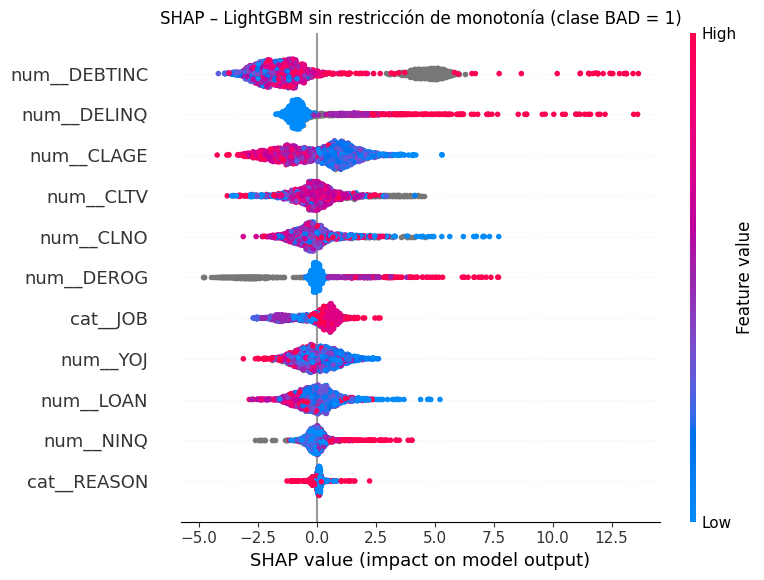

In [32]:
# 1) Saco el modelo y el preprocesador del pipeline
model_light = best_model_lgbm_principal.named_steps["model_light"]
prep = best_model_lgbm_principal.named_steps["prep_light"]

# 2) Transformo X_test y le pongo los nombres de las columnas
nombres = prep.get_feature_names_out()
X_test_trans = pd.DataFrame(prep.transform(X_test), columns=nombres)

# 3) Creo el explainer de SHAP y calculo los valores
explainer = shap.TreeExplainer(model_light)
shap_values = explainer.shap_values(X_test_trans)

# 4) Si devuelve una lista por clase, me quedo con la clase BAD=1
if isinstance(shap_values, list):
    shap_values = shap_values[1]

# 5) Beeswarm: cada punto es un cliente, ordenado por impacto de cada variable
shap.summary_plot(shap_values, X_test_trans, show=False)  
plt.title("SHAP – LightGBM sin restricción de monotonía (clase BAD = 1)", fontsize=12)
plt.tight_layout()  
plt.show()  

In [33]:
signos

{'DEBTINC': 1,
 'DELINQ': 1,
 'DEROG': 1,
 'NINQ': 1,
 'CLAGE': -1,
 'YOJ': -1,
 'CLNO': 0,
 'LOAN': 0,
 'CLTV': 0,
 'REASON': 0,
 'JOB': 0}

c:\Users\karim\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
c:\Users\karim\AppData\Local\Programs\Python\Python313\Lib\site-packages\shap\explainers\_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


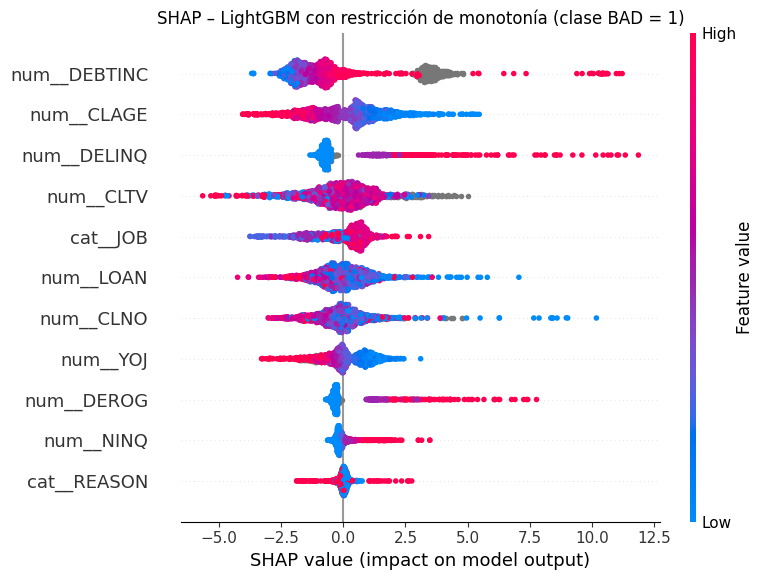

In [34]:
# SHAP en el modelo con monotonía (gs_lgbm_con_mon)

# 1) Saco el mejor pipeline del grid, y de ahí el modelo y el preprocesador
best_model_lgbm_mono = gs_lgbm_con_mon.best_estimator_
model_light = best_model_lgbm_mono.named_steps["model_light"]
prep = best_model_lgbm_mono.named_steps["prep_light"]

# 2) Transformo X_test y le pongo los nombres de las columnas
nombres = prep.get_feature_names_out()
X_test_trans_mono = pd.DataFrame(prep.transform(X_test), columns=nombres)

# 3) Creo el explainer de SHAP y calculo los valores
explainer = shap.TreeExplainer(model_light)
shap_values_mono = explainer.shap_values(X_test_trans_mono)

# 4) Si devuelve una lista por clase, me quedo con la clase BAD=1
if isinstance(shap_values_mono, list):
    shap_values_mono = shap_values_mono[1]

# 5) Beeswarm: cada punto es un cliente, ordenado por impacto de cada variable
shap.summary_plot(shap_values_mono, X_test_trans_mono, show=False)
plt.title("SHAP – LightGBM con restricción de monotonía (clase BAD = 1)", fontsize=12)  
plt.tight_layout() 
plt.show() 

c:\Users\karim\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
c:\Users\karim\AppData\Local\Programs\Python\Python313\Lib\site-packages\shap\explainers\_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(
c:\Users\karim\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
c:\Users\karim\AppData\Local\Programs\Python\Python313\Lib\site-packages\shap\explainers\_tree.py:632: 

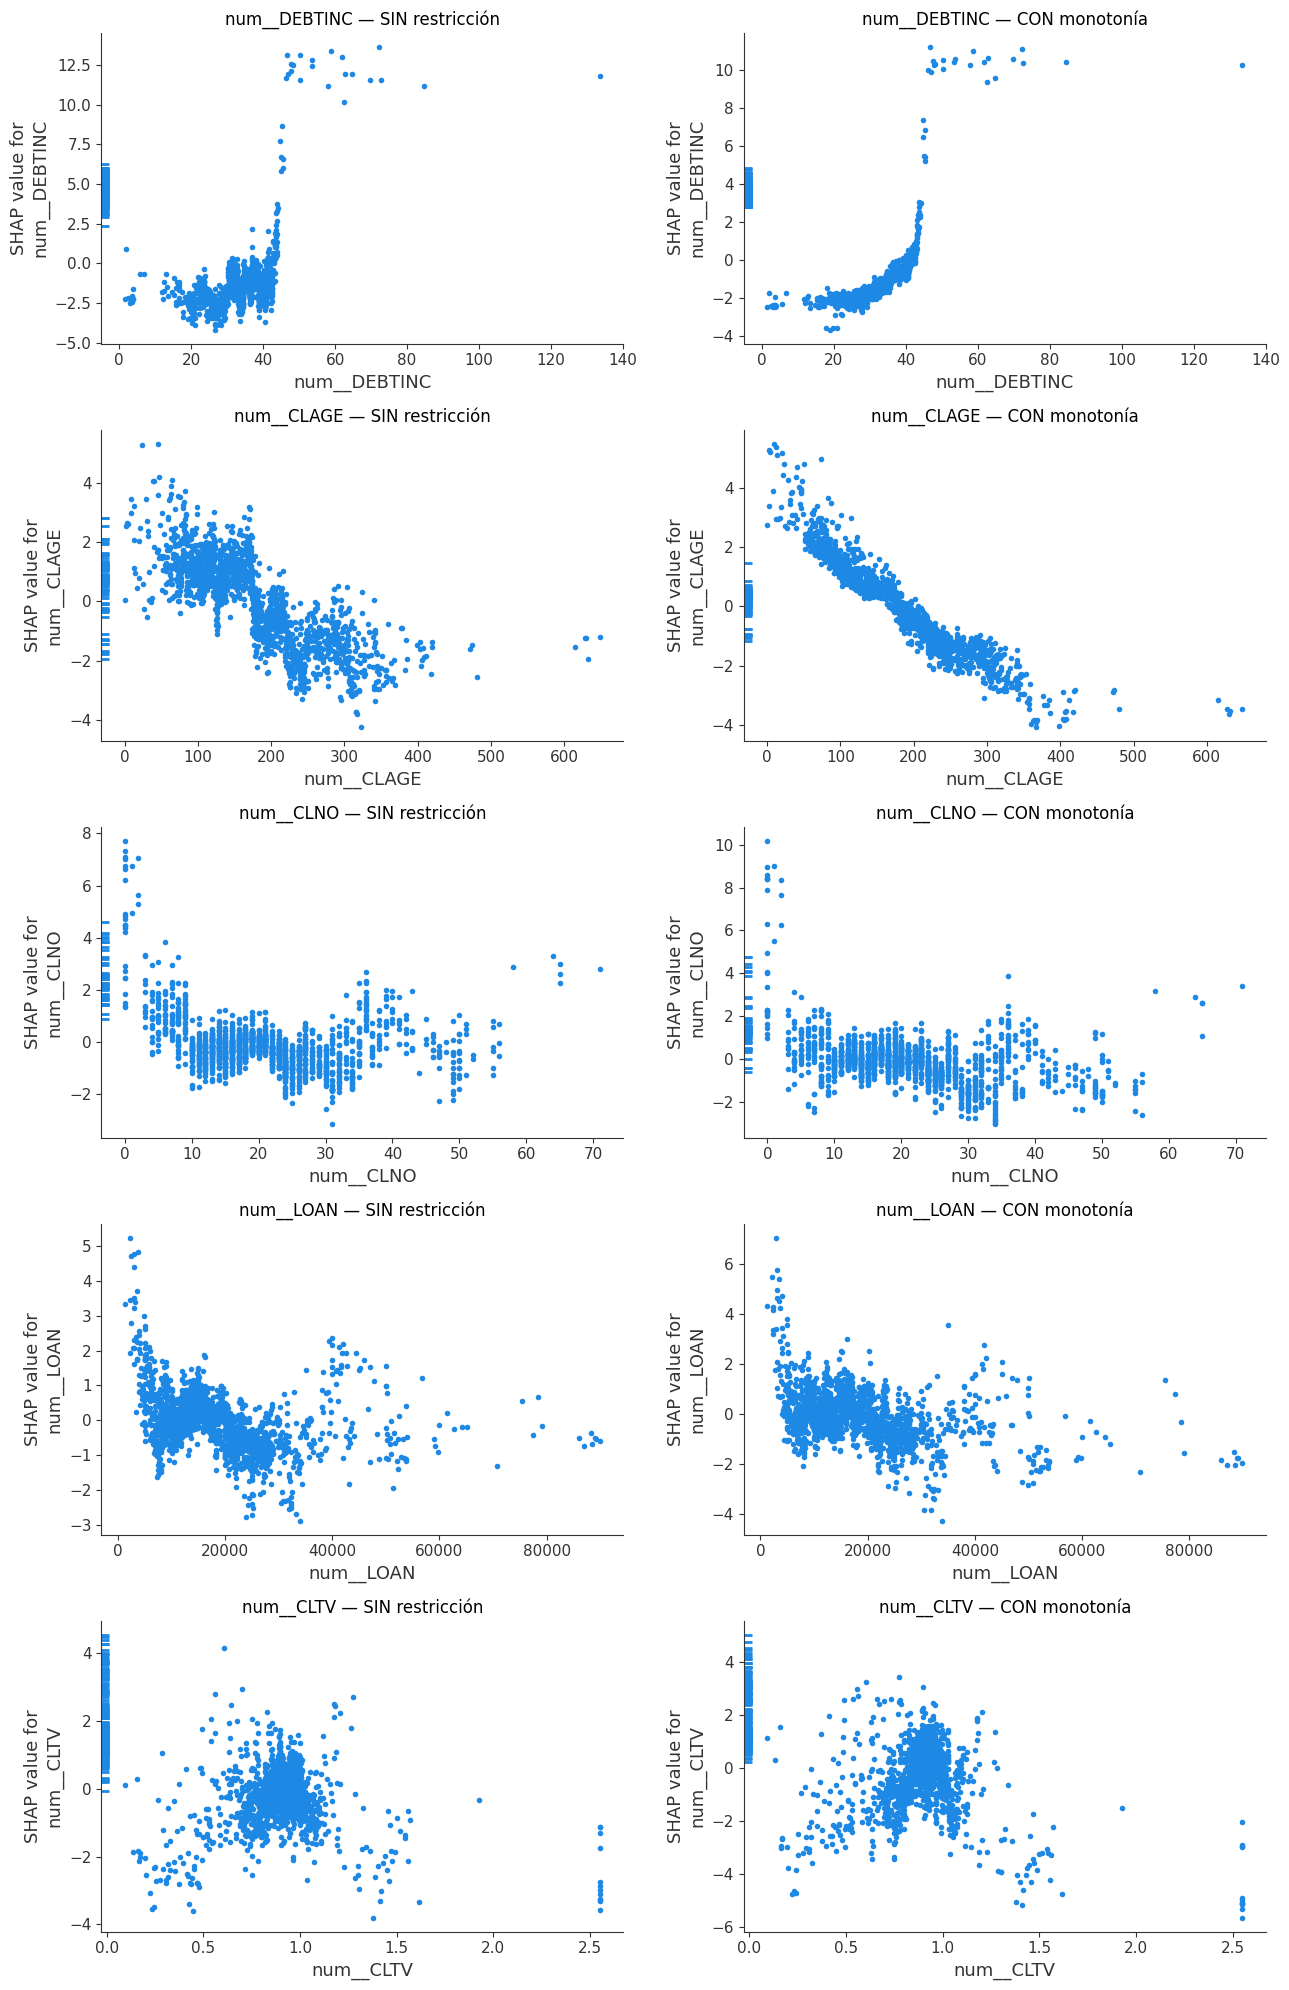

In [35]:
#  SHAP dependence plots: SIN restricción vs CON monotonía

# 1) SHAP del modelo SIN restricción (el original)
prep_orig = best_model_lgbm_principal.named_steps["prep_light"]
model_orig = best_model_lgbm_principal.named_steps["model_light"]

nombres = prep_orig.get_feature_names_out()
X_orig = pd.DataFrame(prep_orig.transform(X_test), columns=nombres)

explainer_orig = shap.TreeExplainer(model_orig)
shap_orig = explainer_orig.shap_values(X_orig)
if isinstance(shap_orig, list):
    shap_orig = shap_orig[1]

# 2) SHAP del modelo CON monotonía (gs_lgbm_con_mon)
best_model_lgbm_mono = gs_lgbm_con_mon.best_estimator_
prep_mono = best_model_lgbm_mono.named_steps["prep_light"]
model_mono = best_model_lgbm_mono.named_steps["model_light"]

X_mono = pd.DataFrame(prep_mono.transform(X_test), columns=nombres)

explainer_mono = shap.TreeExplainer(model_mono)
shap_mono = explainer_mono.shap_values(X_mono)
if isinstance(shap_mono, list):
    shap_mono = shap_mono[1]

# 3) Variables a comparar
variables = ["num__DEBTINC", "num__CLAGE", "num__CLNO", "num__LOAN", "num__CLTV"]

# 4) Dibujo: izquierda sin restricción, derecha con monotonía
fig, axes = plt.subplots(len(variables), 2, figsize=(13, 4 * len(variables)))

for i, var in enumerate(variables):
    # Izquierda: modelo sin restricción
    shap.dependence_plot(var, shap_orig, X_orig, interaction_index=None, ax=axes[i, 0], show=False)
    axes[i, 0].set_title(f"{var} — SIN restricción")

    # Derecha: modelo con monotonía
    shap.dependence_plot(var, shap_mono, X_mono, interaction_index=None, ax=axes[i, 1], show=False)
    axes[i, 1].set_title(f"{var} — CON monotonía")

plt.tight_layout()
plt.show()

El análisis SHAP confirma que el modelo se apoya en variables coherentes con el riesgo de crédito. El beeswarm sitúa a DEBTINC, CLAGE y DELINQ como las más
influyentes, y el color de los puntos muestra que sus direcciones son las esperadas: a mayor DEBTINC o DELINQ, mayor PD; a mayor CLAGE, menor PD.

Los dependence plots comparan el modelo sin restricción frente al que tiene monotonía. En las variables ya monótonas (DEBTINC, CLAGE) la forma apenas
cambia. En CLNO, en cambio, el modelo sin restricción muestra una relación no monótona (zig-zag), que la monotonía obliga a aplanar; esto explica por qué
CLNO se dejó sin restricción y por qué imponerla empeoraba el rendimiento.

En LOAN y CLTV, ambas marcadas como «Revisar» en el contraste binning–Spearman, los dependence plots confirman la decisión de dejarlas sin restricción, aunque por motivos distintos. LOAN presenta una relación claramente no monótona: el SHAP es elevado en los
préstamos de menor importe (mayor riesgo), desciende y se aplana en el tramo medio, sin una pendiente única en todo el rango. La débil correlación negativa de Spearman (ρ = −0,1081) recoge solo esa tendencia media. Imponer una dirección descendente distorsionaría el comportamiento en los importes altos. CLTV, en cambio, muestra una nube dispersa sin dirección estable, coherente con su correlación prácticamente nula (ρ = −0,0528): no existe un patrón monótono robusto que justifique restringir la variable.

En conjunto, SHAP aporta la explicabilidad del modelo (qué variables pesan y en qué dirección) y respalda visualmente las decisiones de monotonía tomadas.

##### 3.4.3 Busqueda de Hiperparámetros LightGBM optimizando neg_log_loss
Hasta ahora hemos optimizado el modelo por AUC, una métrica centrada en la discriminación. Cabe preguntarse si el ajuste perfecto en train (AUC = 1) estárelacionado con esa elección. Por ello, probamos una métrica alternativa, neg_log_loss, que es una regla de puntuación propia: premia a la vez la discriminación y la calibración de las probabilidades.


In [36]:
param_grid_lgbm_opt_log_loss_sin_mon = {
    "model_light__n_estimators" : [100, 300, 500],
    "model_light__max_depth" : [3, 5, 7],
    "model_light__learning_rate" : [0.01, 0.05, 0.1],
    "model_light__min_child_samples": [10, 20, 50, 100],
}  

param_grid_lgbm_opt_log_loss_con_mon = {
    **param_grid_lgbm_opt_log_loss_sin_mon,
    "model_light__monotone_constraints": [direcciones],
}


In [37]:
gs_lgbm_opt_log_loss_sin_mon = GridSearchCV(
    estimator=pl_lgbm,  # El estimator será el pipeline completo: preprocesamiento + modelo
    param_grid=param_grid_lgbm_opt_log_loss_sin_mon, # Hiperparámetros a probar
    cv=cv_estratificado, # Esta CV  estratificada (mantiene el % de BAD en cada fold)
    scoring="neg_log_loss", # Métrica neg log loss para valorar calibracion y discriminacion
    # verbose=1,
    return_train_score=True, # Guarda también el score en train — útil para detectar overfitting
    n_jobs=-1 
)

In [38]:
# Entrenamiento sobre X_train
gs_lgbm_opt_log_loss_sin_mon.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 832, number of negative: 3340
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001017 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1186
[LightGBM] [Info] Number of data points in the train set: 4172, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.199425 -> initscore=-1.389894
[LightGBM] [Info] Start training from score -1.389894
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -

,estimator,Pipeline(step..._state=123))])
,param_grid,"{'model_light__learning_rate': [0.01, 0.05, ...], 'model_light__max_depth': [3, 5, ...], 'model_light__min_child_samples': [10, 20, ...], 'model_light__n_estimators': [100, 300, ...]}"
,scoring,'neg_log_loss'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,transformers,"[('num', ...), ('cat', ...)]"


In [39]:
gs_lgbm_opt_log_loss_con_mon = GridSearchCV(
    estimator=pl_lgbm,  # El estimator será el pipeline completo: preprocesamiento + modelo
    param_grid=param_grid_lgbm_opt_log_loss_con_mon, # Hiperparámetros a probar
    cv=cv_estratificado, # Esta CV  estratificada (mantiene el % de BAD en cada fold)
    scoring="neg_log_loss", # Métrica neg log loss para valorar calibracion y discriminacion
    # verbose=1,
    return_train_score=True, # Guarda también el score en train — útil para detectar overfitting
    n_jobs=-1 
)

In [40]:
# Entrenamiento sobre X_train
gs_lgbm_opt_log_loss_con_mon.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 832, number of negative: 3340
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000956 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1186
[LightGBM] [Info] Number of data points in the train set: 4172, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.199425 -> initscore=-1.389894
[LightGBM] [Info] Start training from score -1.389894
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b

,estimator,Pipeline(step..._state=123))])
,param_grid,"{'model_light__learning_rate': [0.01, 0.05, ...], 'model_light__max_depth': [3, 5, ...], 'model_light__min_child_samples': [10, 20, ...], 'model_light__monotone_constraints': [[0, -1, ...]], ...}"
,scoring,'neg_log_loss'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,transformers,"[('num', ...), ('cat', ...)]"


##### 3.4.4 Auditoría por modelo (optimización AUC vs neg_log_loss & con/sin monotonía)

In [41]:
# modelos
modelos = [
    (gs_lgbm_principal_1.best_estimator_,    "Principal (AUC, sin mono)"),
    (gs_lgbm_con_mon.best_estimator_,  "AUC + monotonía"),
    (gs_lgbm_opt_log_loss_sin_mon.best_estimator_,  "log loss, sin mono"),
    (gs_lgbm_opt_log_loss_con_mon.best_estimator_,  "log loss + monotonía"),
]

filas = [metricas(modelo, nombre) for modelo, nombre in modelos]
tabla_auditoria_modelos = pd.DataFrame(filas)
tabla_auditoria_modelos.round(4)

c:\Users\karim\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
c:\Users\karim\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\karim\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
c:\Users\karim\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: User

c:\Users\karim\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
c:\Users\karim\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\karim\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
c:\Users\karim\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: User

,Modelo,AUC train,AUC test,Gini train,Gini test,KS Train,KS Test,Brier train,Brier test,Log loss train,Log loss test
0,"Principal (AUC, sin mono)",1.0000,0.9691,1.0000,0.9382,1.0000,0.8238,0.0000,0.0585,0.0011,0.2369
1,AUC + monotonía,1.0000,0.9547,1.0000,0.9094,1.0000,0.7831,0.0007,0.0611,0.0099,0.2402
2,"log loss, sin mono",0.9977,0.9587,0.9953,0.9175,0.9469,0.7859,0.0210,0.0609,0.0899,0.2015
3,log loss + monotonía,0.9797,0.9497,0.9594,0.8993,0.8485,0.7580,0.0419,0.0638,0.1513,0.2156


##### 3.4.5 Conclusión de la comparativa y modelo seleccionado

Se han comparado cuatro configuraciones de LightGBM cruzando la métrica de optimización {AUC, neg_log_loss} con la presencia o no de monotonía:

- Solo el modelo optimizado por AUC y sin monotonía alcanza un AUC en train de 1,00. Cualquier restricción lo reduce levemente, por lo que el ajuste perfecto no es un sobreajuste irreducible.
- El modelo principal (AUC, sin monotonía) obtiene el mejor AUC en test, aunque las diferencias entre modelos son muy pequeñas.
- La calibración (Brier) apenas varía; el mejor sigue siendo el principal, de modo que neg_log_loss no aportó la mejora de calibración esperada.

**Decisión.** 
**Se mantiene como benchmark el modelo optimizado por AUC y sin monotonía**, por ser el mejor en discriminación, calibración y log loss. El resto se conserva como análisis metodológico de respaldo.

In [42]:
styled_tabla_auditoria_modelos = (
    tabla_auditoria_modelos.style
    .set_caption("Tabla 14 – Metricas Modelo principal .")
    .set_table_styles([
        # Cabecera
        {
            "selector": "th",
            "props": [
                ("background-color",  "#1B6E6E"),
                ("color", "white"),
                ("font-weight", "bold"),
                ("text-align", "center"),   
                ("border", "1px solid black"),
                ("padding", "1px 3px")
            ]
        },
        # Celdas
        {
            "selector": "td",
            "props": [
                ("text-align", "center"),    
                ("border", "1px solid black"),
                ("padding", "1px 3px")
            ]
        },
        # Caption
        {
            "selector": "caption",
            "props": [
                ("caption-side", "bottom"),
                ("font-size", "12px"),
                ("font-style", "italic"),
                ("text-align", "center")
            ]
        }
    ])
    .format(precision=4)
    .hide(axis="index")
)


styled_tabla_auditoria_modelos

Modelo,AUC train,AUC test,Gini train,Gini test,KS Train,KS Test,Brier train,Brier test,Log loss train,Log loss test
"Principal (AUC, sin mono)",1.0000,0.9691,1.0000,0.9382,1.0000,0.8238,0.0000,0.0585,0.0011,0.2369
AUC + monotonía,1.0000,0.9547,1.0000,0.9094,1.0000,0.7831,0.0007,0.0611,0.0099,0.2402
"log loss, sin mono",0.9977,0.9587,0.9953,0.9175,0.9469,0.7859,0.0210,0.0609,0.0899,0.2015
log loss + monotonía,0.9797,0.9497,0.9594,0.8993,0.8485,0.7580,0.0419,0.0638,0.1513,0.2156


### Decisión final del modelo tomado 

Se han comparado cuatro configuraciones de LightGBM cruzando la métrica de optimización (AUC vs log loss) con la presencia o no de monotonía.

**El ajuste perfecto en train es estructural, no un defecto.** El AUC en train alcanza 1,0000 tanto en el modelo sin restringir como en el modelo con monotonía (ambos sobre la configuración 500/7/0,1/10). Que la restricción de monotonía no rompa ese ajuste perfecto confirma que procede de la estructura del HMEQ donde las variables continuas de alta granularidad (DEBTINC, CLAGE, CLTV)  permiten particiones muy específicas y no de una calibración subóptima del algoritmo. Solo las variantes optimizadas por log loss, que exploran la rejilla con otra métrica, quedan por debajo en train (AUC 0,9977 y 0,9797).

**Modelo seleccionado: AUC + monotonía.** El criterio no es maximizar las métricas, sino la explicabilidad. Frente al modelo sin restringir, imponer monotonía tiene un coste modesto y repartido: la discriminación baja (AUC test 0,9547 vs 0,9691; KS 0,7831 vs 0,8238) y la calibración empeora ligeramente (Brier 0,0611 vs 0,0585; log loss 0,2402 vs 0,2369). Todas las diferencias son pequeñas. Entre las dos configuraciones monótonas se prefiere esta por su mejor discriminación y mejor Brier frente a "log loss + monotonía" (0,9497 / 0,0638), que solo aventaja en su propio log loss.

El beneficio que justifica ese coste es que las restricciones garantizan relaciones direccionales y coherentes entre cada variable y la probabilidad de incumplimiento (a mayor DEBTINC, DELINQ, DEROG o NINQ, mayor riesgo; a mayor CLAGE o YOJ, menor), aportando interpretabilidad y defensa regulatoria en paridad con el modelo principal WoE + Regresión Logística. Los SHAP dependence plots confirman visualmente esa monotonía.

In [43]:
best_model_lgbm_mono

,steps,"[('prep_light', ...), ('model_light', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


#### 4. Comprobación de ausencia de data leakage 

El ajuste perfecto sobre entrenamiento (AUC train = 1,0000) tiene dos explicaciones posibles: (a) una propiedad estructural del dataset, o (b) un problema de data leakage, es decir, que alguna variable predictora contenga indirectamente información de la variable objetivo. Descartar (b) es imprescindible antes de aceptar (a).

Para ello se realizan tres comprobaciones de menor a mayor potencia:
1. Correlación de cada variable con el objetivo BAD (señal preliminar).
2. Poder predictivo de cada variable en solitario (prueba definitiva).
3. Revisión conceptual de las variables de historial crediticio (DELINQ, DEROG).

##### 4.1 Correlación de cada variable con el objetivo BAD .

In [44]:
vars_numericas

['LOAN',
 'YOJ',
 'DEROG',
 'DELINQ',
 'CLAGE',
 'NINQ',
 'CLNO',
 'DEBTINC',
 'MORTDUE',
 'VALUE']

In [45]:
filas = []
for var in vars_numericas:
    correlacion = hmeq[var].corr(hmeq["BAD"], method="spearman")

    if abs(correlacion) > 0.8:
        nivel = "SOSPECHOSA (posible leakage)"
    elif abs(correlacion) > 0.5:
        nivel = "alta (revisar)"
    else:
        nivel = "normal"

    filas.append([var, round(correlacion, 4), nivel])

# 3) Lo muestro como tabla
check_corr = pd.DataFrame(filas, columns=["variable", "correlacion", "nivel"])
check_corr


,variable,correlacion,nivel
0,LOAN,-0.1084,normal
1,YOJ,-0.0567,normal
2,DEROG,0.2735,normal
3,DELINQ,0.3322,normal
4,CLAGE,-0.1863,normal
5,NINQ,0.1516,normal
6,CLNO,-0.0149,normal
7,DEBTINC,0.1464,normal
8,MORTDUE,-0.0766,normal
9,VALUE,-0.0767,normal


##### 4.2 Poder predictivo de cada variable individual

Si una sola variable alcanzase un AUC cercano a 1, sería el objetivo disfrazado (leakage). Se entrena un modelo trivial con una única variable y se mide su AUC sobre test. Si ninguna variable supera por sí sola un AUC moderado, el ajuste perfecto procede de la combinación de variables, no de una contaminada.

In [46]:
# PRUEBA 2.1: AUC de cada variable POR SEPARADO
# Si una sola variable diera AUC ≈ 1, sería el target disfrazado (leakage)
filas = []
for var in vars_numericas:
    x = hmeq[var].fillna(hmeq[var].median()) # ajustamos por mediana para esta prueba
    y = hmeq["BAD"]

    # Uso la variable como "score". Si correlaciona negativo, invierto el signo
    # para que el AUC quede por encima de 0.5 y sea interpretable
    if x.corr(y) < 0:
        x = -x

    auc_var = roc_auc_score(y, x)
    filas.append([var, round(auc_var, 4)])

check_auc = pd.DataFrame(filas, columns=["variable", "AUC_individual"])
check_auc = check_auc.sort_values("AUC_individual", ascending=False)
check_auc

,variable,AUC_individual
3,DELINQ,0.6641
4,CLAGE,0.6309
2,DEROG,0.6098
5,NINQ,0.5961
0,LOAN,0.5783
7,DEBTINC,0.5611
9,VALUE,0.5536
8,MORTDUE,0.5530
1,YOJ,0.5392
6,CLNO,0.5102


In [47]:
# PRUEBA 2.2 (sin imputar): AUC de cada variable usando solo sus valores no nulos
filas = []
for var in vars_numericas:
    # Me quedo solo con las filas donde la variable NO es nula (sin inventar valores)
    mask = hmeq[var].notna()
    x = hmeq.loc[mask, var]
    y = hmeq.loc[mask, "BAD"]

    if x.corr(y) < 0:          # invierto signo si correlaciona negativo
        x = -x

    auc_var = roc_auc_score(y, x)
    filas.append([var, round(auc_var, 4), mask.sum()])   # mask.sum() = nº de filas usadas

check_auc = pd.DataFrame(filas, columns=["variable", "AUC_individual", "N_usado"])
check_auc = check_auc.sort_values("AUC_individual", ascending=False)
check_auc

,variable,AUC_individual,N_usado
3,DELINQ,0.6720,5380
7,DEBTINC,0.6509,4693
4,CLAGE,0.6353,5652
2,DEROG,0.6162,5252
5,NINQ,0.6019,5450
0,LOAN,0.5783,5960
9,VALUE,0.5570,5848
8,MORTDUE,0.5554,5442
1,YOJ,0.5404,5445
6,CLNO,0.5108,5738


In [48]:
# PRUEBA 2.3 (MNAR): los NaN se envían a un extremo, replicando lo que hace el árbol
filas = []
for var in vars_numericas:
    y = hmeq["BAD"]
    x = hmeq[var].copy()

    # Oriento la variable: si correlaciona negativo, invierto el signo
    # (así "más alto = más riesgo" en todas)
    if hmeq[var].corr(y) < 0:
        x = -x

    # MNAR: los NaN los mando al extremo de MÁS riesgo (como un split que los separa)
    # Uso un valor mayor que cualquier observado, para aislarlos en su propio grupo
    valor_extremo = x.max() + 1
    x = x.fillna(valor_extremo)

    auc_var = roc_auc_score(y, x)
    filas.append([var, round(auc_var, 4)])

check_auc = pd.DataFrame(filas, columns=["variable", "AUC_individual"])
check_auc = check_auc.sort_values("AUC_individual", ascending=False)
check_auc

,variable,AUC_individual
7,DEBTINC,0.8261
4,CLAGE,0.6291
3,DELINQ,0.6214
9,VALUE,0.5953
0,LOAN,0.5783
5,NINQ,0.5727
2,DEROG,0.5652
8,MORTDUE,0.5475
1,YOJ,0.5148
6,CLNO,0.5145


In [49]:
# Unión Prueba 2.1 y 2.3 para la memoria 
import pandas as pd
from sklearn.metrics import roc_auc_score

filas = []
for var in vars_numericas:
    y = hmeq["BAD"]

    #  AUC con imputación por mediana (Prueba 2.1) 
    x_med = hmeq[var].fillna(hmeq[var].median())
    if hmeq[var].corr(y) < 0:        # oriento: más alto = más riesgo
        x_med = -x_med
    auc_mediana = roc_auc_score(y, x_med)

    #  AUC con tratamiento MNAR, NaN al extremo de riesgo (Prueba 2.3) 
    x_mnar = hmeq[var].copy()
    if hmeq[var].corr(y) < 0:
        x_mnar = -x_mnar
    x_mnar = x_mnar.fillna(x_mnar.max() + 1)   # aíslo los nulos en su grupo
    auc_mnar = roc_auc_score(y, x_mnar)

    filas.append([var, round(auc_mediana, 3), round(auc_mnar, 3)])

# Tabla final: variable, AUC con mediana, AUC con MNAR
check_auc = pd.DataFrame(filas, columns=["Variable", "AUC (mediana)", "AUC (MNAR)"])
check_auc = check_auc.sort_values("AUC (MNAR)", ascending=False)
check_auc


filas = []
for var in vars_numericas:
    y = hmeq["BAD"]

    #  AUC con imputación por mediana (Prueba 2.1) 
    x_med = hmeq[var].fillna(hmeq[var].median())
    if hmeq[var].corr(y) < 0:        # oriento: más alto = más riesgo
        x_med = -x_med
    auc_mediana = roc_auc_score(y, x_med)

    #  AUC con tratamiento MNAR, NaN al extremo de riesgo (Prueba 2.3) 
    x_mnar = hmeq[var].copy()
    if hmeq[var].corr(y) < 0:
        x_mnar = -x_mnar
    x_mnar = x_mnar.fillna(x_mnar.max() + 1)   # aíslo los nulos en su grupo
    auc_mnar = roc_auc_score(y, x_mnar)

    filas.append([var, round(auc_mediana, 3), round(auc_mnar, 3)])

# Tabla final: variable, AUC con mediana, AUC con MNAR
check_auc = pd.DataFrame(filas, columns=["Variable", "AUC (mediana)", "AUC (MNAR)"])
check_auc = check_auc.sort_values("AUC (MNAR)", ascending=False)
check_auc

styled_check_auc = (
    check_auc.style
    .set_caption(" AUC Individual (Missing = mediana vs Missing = extremo).")
    .set_table_styles([
        # Cabecera
        {
            "selector": "th",
            "props": [
                ("background-color",  "#1B6E6E"),
                ("color", "white"),
                ("font-weight", "bold"),
                ("text-align", "center"),   
                ("border", "1px solid black"),
                ("padding", "1px 3px"),
            ]
        },
        # Celdas
        {
            "selector": "td",
            "props": [
                ("text-align", "center"),    
                ("border", "1px solid black"),
                ("padding", "1px 3px")
            ]
        },
        # Caption
        {
            "selector": "caption",
            "props": [
                ("caption-side", "bottom"),
                ("font-size", "16px"),
                ("font-style", "italic"),
                ("text-align", "center")
            ]
        }
    ])
    .format(precision=3)
    .hide(axis="index")
)


styled_check_auc


Variable,AUC (mediana),AUC (MNAR)
DEBTINC,0.561,0.826
CLAGE,0.631,0.629
DELINQ,0.664,0.621
VALUE,0.554,0.595
LOAN,0.578,0.578
NINQ,0.596,0.573
DEROG,0.610,0.565
MORTDUE,0.553,0.547
YOJ,0.539,0.515
CLNO,0.510,0.515


Se mide el AUC de cada variable por separado. Si una sola alcanzara un AUC cercano a 1, sería el objetivo disfrazado (leakage). Los NaN se envían a un extremo, replicando el tratamiento nativo de LightGBM y respetando su naturaleza MNAR.

La más predictiva es DEBTINC (AUC 0,8261); el resto, por debajo de 0,63. Ninguna se acerca a 1: un predictor fuerte, pero lejos de contener el target. Como el modelo completo sí alcanza AUC = 1 en train, ese ajuste perfecto procede de la combinación de variables, no de una contaminada. Se descarta el leakage. Además, DEBTINC sube de 0,56 (mediana) a 0,83 al aislar sus NaN, confirmando que su ausencia es informativa (MNAR).

In [50]:
# Comprobar la proporción de BAD en train y test
print("Proporción de BAD en train:", round(y_train.mean(), 4))
print("Proporción de BAD en test :", round(y_test.mean(), 4))

Proporción de BAD en train: 0.1994
Proporción de BAD en test : 0.1997


#### 5. Importancia de las variables

In [51]:
# Forma correcta — scikit-learn extrae los nombres automáticamente
nombres_features_reales = best_model_lgbm_mono.named_steps["prep_light"].get_feature_names_out()
print(nombres_features_reales)

['num__LOAN' 'num__YOJ' 'num__DEROG' 'num__DELINQ' 'num__CLAGE'
 'num__NINQ' 'num__CLNO' 'num__DEBTINC' 'num__CLTV' 'cat__REASON'
 'cat__JOB']


In [52]:
#  importancia por número de splits 
model_light = best_model_lgbm_mono.named_steps["model_light"]
importancias = pd.Series(
    model_light.feature_importances_,
    index=nombres_features_reales
).sort_values(ascending=False)

print(importancias)

num__CLTV       3425
num__LOAN       3140
num__CLNO       2764
num__CLAGE      1036
num__DEBTINC    1002
cat__JOB         965
num__YOJ         705
num__DELINQ      583
cat__REASON      359
num__DEROG       338
num__NINQ        279
dtype: int32


DELINQ tiene IV (Information Value) de 0.63 — el segundo más alto del dataset. Es una variable con justificación causal directa: un cliente que ya está en mora tiene una probabilidad de default estructuralmente más alta. LightGBM con max_depth=7 puede crear reglas muy específicas sobre DELINQ que separan perfectamente el train.

Sin embargo, al revisar la importacia de las variables, El AUC train perfecto no es atribuible a una variable dominante sino a la combinación de max_depth=7 con variables continuas de alta granularidad como CLAGE y CLTV, que permiten al modelo crear reglas muy específicas sobre el train. Sin embargo, la diferencia train/validación de 0.0504 y el AUC test de 0.9691 — superior al de validación cruzada — confirman que el modelo generaliza correctamente.

In [53]:
# Importancia por ganancia — más robusta para comparación entre variables
importancias_gain = pd.Series(
    model_light.booster_.feature_importance(importance_type="gain"),
    index=nombres_features_reales
).sort_values(ascending=False)

print(importancias_gain)

num__DEBTINC    7951.408637
num__CLTV       2739.242580
num__CLNO       2505.748006
num__LOAN       2320.347048
num__CLAGE      1727.743838
num__DELINQ     1485.048596
cat__JOB        1064.862891
num__YOJ         916.251497
num__DEROG       837.071703
num__NINQ        404.355367
cat__REASON      267.834179
dtype: float64


In [54]:
import pandas as pd

# 1. Calculo las importancias por ganancia (es una Serie)
importancias_gain = pd.Series(
    model_light.booster_.feature_importance(importance_type="gain"),
    index=nombres_features_reales
).sort_values(ascending=False)

# 2. Convierto la Serie en DataFrame con dos columnas con nombre
tabla_imp = importancias_gain.reset_index()
tabla_imp.columns = ["Variable", "Ganancia"]

# 3. Aplico el mismo estilo que tu tabla de AUC
styled_imp = (
    tabla_imp.style
    .set_caption("Importancia por ganancia (LightGBM).")
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("background-color",  "#1B6E6E"),
                ("color", "white"),
                ("font-weight", "bold"),
                ("text-align", "center"),   
                ("border", "1px solid black"),
                ("padding", "1px 3px")
            ]
        },
        {   # Celdas
            "selector": "td",
            "props": [
                ("text-align", "center"),
                ("border", "1px solid black"),
                ("padding", "1px 3px"),
            ]
        },
        {   # Caption
            "selector": "caption",
            "props": [
                ("caption-side", "bottom"),
                ("font-size", "12px"),
                ("font-style", "italic"),
                ("text-align", "center"),
            ]
        },
    ])
    .format({"Ganancia": "{:.0f}"})   # ganancia sin decimales (son números grandes)
    .hide(axis="index")
)

styled_imp

Variable,Ganancia
num__DEBTINC,7951
num__CLTV,2739
num__CLNO,2506
num__LOAN,2320
num__CLAGE,1728
num__DELINQ,1485
cat__JOB,1065
num__YOJ,916
num__DEROG,837
num__NINQ,404


In [55]:
styled_imp = (
    tabla_imp.style
    .set_caption("Importancia por ganancia (LightGBM).")
    .set_table_styles([
        # Cabecera
        {
            "selector": "th",
            "props": [
                ("background-color",  "#1B6E6E"),
                ("color", "white"),
                ("font-weight", "bold"),
                ("text-align", "center"),   
                ("border", "1px solid black"),
                ("padding", "1px 3px")
            ]
        },
        # Celdas
        {
            "selector": "td",
            "props": [
                ("text-align", "center"),    
                ("border", "1px solid black"),
                ("padding", "1px 3px")
            ]
        },
        # Caption
        {
            "selector": "caption",
            "props": [
                ("caption-side", "bottom"), # Si lo quieres arriba, cambia "bottom" por "top"
                ("font-size", "17px"),      # Tamaño ampliado
                # ("font-weight", "bold"),    # Negrita añadida para que destaque
                ("font-style", "italic"),
                ("text-align", "center")
            ]
        }
    ])
    .format(precision=1)
    .hide(axis="index")
)
styled_imp

Variable,Ganancia
num__DEBTINC,7951.4
num__CLTV,2739.2
num__CLNO,2505.7
num__LOAN,2320.3
num__CLAGE,1727.7
num__DELINQ,1485.0
cat__JOB,1064.9
num__YOJ,916.3
num__DEROG,837.1
num__NINQ,404.4


Conclusión revisada
La causa del AUC train perfecto no es una variable única sino un patrón distribuido. Hay tres hallazgos relevantes:  

DEBTINC es la variable más informativa por ganancia — cada vez que el modelo la usa para dividir, aporta mucha reducción de error. Sin embargo se usa relativamente poco en splits porque es una variable con muchos missings en el dataset HMEQ, lo que limita su uso.  

CLAGE y CLTV dominan en número de splits — son variables continuas con alta granularidad que permiten al modelo crear muchas divisiones específicas. Esto contribuye directamente al AUC train perfecto con max_depth=7.  

DELINQ sube del puesto 9 al 7 en ganancia — confirma que cuando el modelo la usa, cada split es muy informativo. Esto es consistente con su IV de 0.63 y su justificación causal.

Conclision_
El análisis de importancia de variables revela que el AUC-ROC perfecto en 
train no es atribuible a una variable dominante sino a la combinación de 
variables continuas de alta granularidad — especialmente DEBTINC, CLAGE y 
CLTV — que con max_depth=7 permiten al modelo crear reglas muy específicas 
sobre el conjunto de entrenamiento. Por importancia por ganancia, DEBTINC 
emerge como la variable más informativa por split, seguida de CLAGE y CLTV. 
DELINQ, pese a tener el segundo IV más alto del dataset, ocupa la séptima 
posición en ganancia, consistente con su naturaleza discreta de pocos valores 
únicos. La diferencia train/validación de 0.0504 y el AUC-ROC en test de 
0.9691 confirman que el modelo generaliza correctamente a datos no vistos.

#### 6. Visualización 

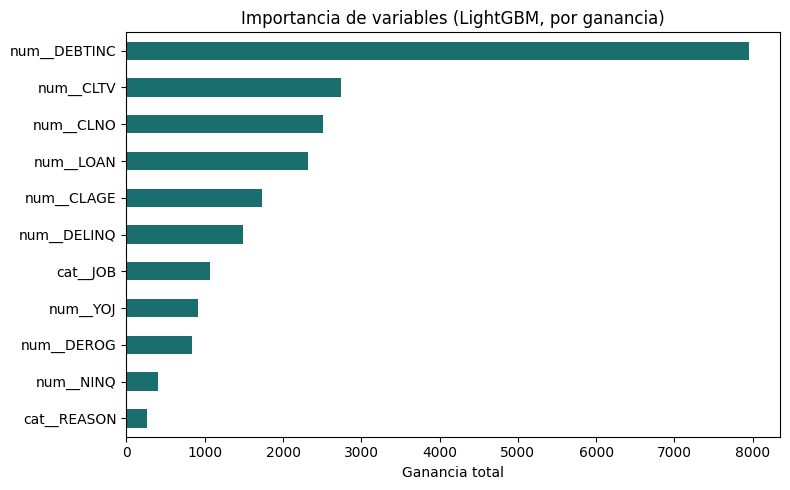

In [56]:
# Importancia de las variables por ganancia (gain)
# La ganancia mide cuánto reduce el error cada variable al entrar en los splits del árbol

plt.figure(figsize=(8, 5))       
importancias_gain.sort_values().plot(              
    kind="barh",                
    color= "#1B6E6E"
)
plt.title("Importancia de variables (LightGBM, por ganancia)")  
plt.xlabel("Ganancia total")                              
plt.tight_layout()
plt.show() 

Confirma qué variables contribuyen más al poder predictivo del modelo, en línea con el análisis de IV del EDA.

c:\Users\karim\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
c:\Users\karim\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\karim\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
c:\Users\karim\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: User

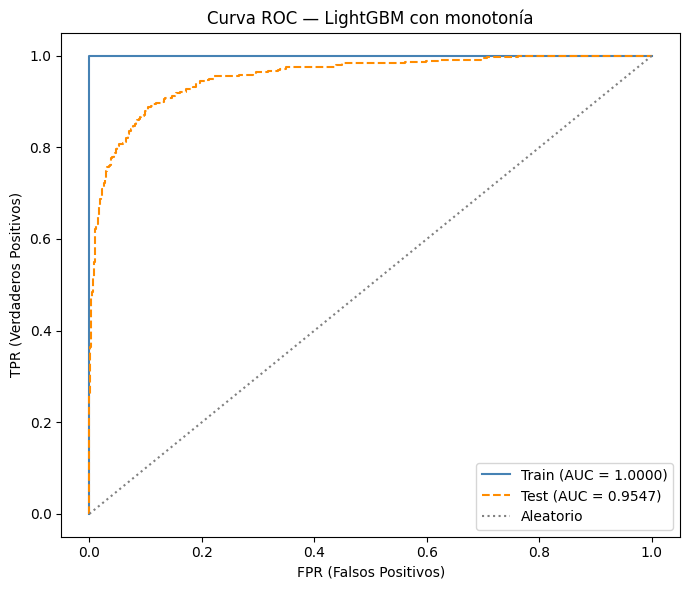

AUC train: 1.0000 | val CV: 0.9310 | test: 0.9547


In [57]:
from sklearn.metrics import roc_curve, roc_auc_score
# PD predicha (prob. de BAD=1) en train y test — modelo CON monotonía (el que va al Cap 6)
p_train = best_model_lgbm_mono.predict_proba(X_train)[:, 1]
p_test  = best_model_lgbm_mono.predict_proba(X_test)[:, 1]
# Puntos (FPR, TPR) de la curva ROC y AUC de cada conjunto
fpr_train, tpr_train, _ = roc_curve(y_train, p_train)
fpr_test,  tpr_test,  _ = roc_curve(y_test,  p_test)
auc_train = roc_auc_score(y_train, p_train)
auc_test  = roc_auc_score(y_test,  p_test)
auc_val   = gs_lgbm_con_mon.best_score_           # AUC de validación cruzada (no es curva)
# Gráfico: curva train, curva test y diagonal de referencia
plt.figure(figsize=(7, 6))
plt.plot(fpr_train, tpr_train, color="steelblue",  label=f"Train (AUC = {auc_train:.4f})")
plt.plot(fpr_test,  tpr_test,  color="darkorange", linestyle="--", label=f"Test (AUC = {auc_test:.4f})")
plt.plot([0, 1], [0, 1], color="gray", linestyle=":", label="Aleatorio")
plt.xlabel("FPR (Falsos Positivos)")
plt.ylabel("TPR (Verdaderos Positivos)")
plt.title("Curva ROC — LightGBM con monotonía")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()
print(f"AUC train: {auc_train:.4f} | val CV: {auc_val:.4f} | test: {auc_test:.4f}")

La curva ROC del modelo LightGBM con monotonía muestra una capacidad discriminante alta en test (AUC = 0,9547) frente a un ajuste perfecto en train (AUC = 1,0000). La distancia entre ambas curvas refleja un sobreajuste contenido; que ese ajuste perfecto persista pese a la restricción de monotonía refuerza que es una propiedad estructural del dataset, no un defecto de calibración..

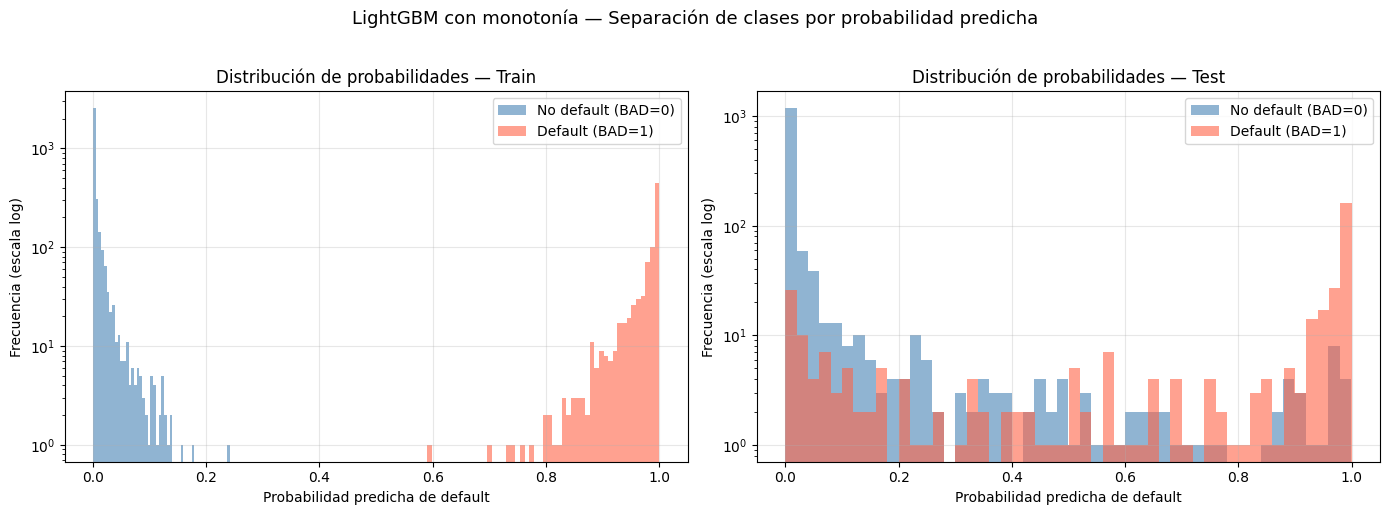

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Train
axes[0].hist(p_train[y_train == 0], bins=50, alpha=0.6, color="steelblue", label="No default (BAD=0)")
axes[0].hist(p_train[y_train == 1], bins=50, alpha=0.6, color="tomato",    label="Default (BAD=1)")
axes[0].set_yscale("log")
axes[0].set_title("Distribución de probabilidades — Train")
axes[0].set_xlabel("Probabilidad predicha de default")
axes[0].set_ylabel("Frecuencia (escala log)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Test
axes[1].hist(p_test[y_test == 0], bins=50, alpha=0.6, color="steelblue", label="No default (BAD=0)")
axes[1].hist(p_test[y_test == 1], bins=50, alpha=0.6, color="tomato",    label="Default (BAD=1)")
axes[1].set_yscale("log")
axes[1].set_title("Distribución de probabilidades — Test")
axes[1].set_xlabel("Probabilidad predicha de default")
axes[1].set_ylabel("Frecuencia (escala log)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle("LightGBM con monotonía — Separación de clases por probabilidad predicha", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

La distribución de probabilidades predichas ilustra visualmente la naturaleza 
del overfitting detectado. En train, el modelo asigna probabilidades 
concentradas en los extremos — próximas a 0 para no defaults y próximas a 1 
para defaults — con separación prácticamente perfecta entre clases. En test, 
aparece solapamiento en la zona central (0.2–0.8), correspondiente a casos 
borderline donde las características del solicitante no permiten una 
clasificación inequívoca. Este solapamiento, ausente en train, explica la 
diferencia entre AUC-ROC train (1.0000) y AUC-ROC test (0.9691), y confirma 
que el modelo generaliza correctamente aunque no de forma perfecta.

#### 7. Persistencia de artefactos

In [59]:
# Persistencia de artefactos — consumidos por el notebook 05 de comparación
import joblib
from pathlib import Path

models_dir = Path("../models")
models_dir.mkdir(exist_ok=True)

# 1) Pipeline completo: preprocesamiento (CLTV + OrdinalEncoder) + LGBMClassifier
#    Guardamos el Pipeline entero para que el 05 pueda llamar predict_proba(X_test)
#    directamente sobre datos crudos, sin reconstruir transformaciones
joblib.dump(best_model_lgbm_mono, models_dir / "lgbm_pipeline.pkl")

# 2) X_test / y_test compartidos — el notebook de XGBoost NO los duplicará
#    (son idénticos por construcción: mismo random_state=123 + stratify)
X_test.to_pickle(models_dir / "boosting_X_test.pkl")
y_test.to_pickle(models_dir / "boosting_y_test.pkl")
X_train.to_pickle(models_dir / "boosting_X_train.pkl")
y_train.to_pickle(models_dir / "boosting_y_train.pkl")

print("✓ Artefactos LightGBM guardados en:", models_dir.resolve())
print(f"  - lgbm_pipeline.pkl      (Pipeline: ColumnTransformer + LGBMClassifier)")
print(f"  - boosting_X_test.pkl    (shape: {X_test.shape})")
print(f"  - boosting_y_test.pkl    (shape: {y_test.shape}, default rate: {y_test.mean():.3f})")
print(f"  - boosting_X_train.pkl   (shape: {X_train.shape})")
print(f"  - boosting_y_train.pkl   (shape: {y_train.shape}, default rate: {y_train.mean():.3f})")

✓ Artefactos LightGBM guardados en: C:\Users\karim\Desktop\MECDIA\TFM\Dataset_Credit_Risk_Model\Mygit\models
  - lgbm_pipeline.pkl      (Pipeline: ColumnTransformer + LGBMClassifier)
  - boosting_X_test.pkl    (shape: (1788, 12))
  - boosting_y_test.pkl    (shape: (1788,), default rate: 0.200)
  - boosting_X_train.pkl   (shape: (4172, 12))
  - boosting_y_train.pkl   (shape: (4172,), default rate: 0.199)
